In [1]:
from sympy import *
from delierium.infinitesimals import overdetermined_system_ode, janet_basis_from_ode
from delierium.janet_basis import JanetBasis
from delierium.helpers import is_derivative, eq, ltf
from delierium.matrix_order import Context
import functools
from operator import mul
from pprint import pprint

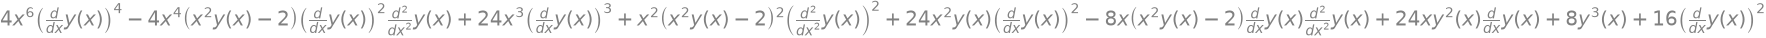

.........................


Janet basis


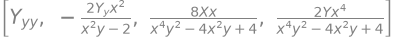

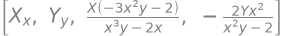

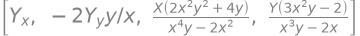

In [2]:
# Schwarz, Example 5.13, p.214"
x = Symbol('x')
y = Function("y")(x)
d0 = y
d1 = diff(y, x)
d2 = diff(d1, x)
d3 = diff(d2, x)
d4 = diff(d3, x)
ode = x**2 *((x**2) * d0 - 2)**2 * d2**2 \
- 4*x**4 * (x**2 * d0 - 2)*d2 * d1**2 \
- 8*x*(x**2 * d0 - 2)*d2*d1 \
+ 4*x**6 * d1**4 \
+ 24*x**3 * d1**3 \
+ 24*x**2 * d1**2 *d0 \
+ 16*d1**2 \
+ 24*x*d1*d0**2 \
+ 8*d0**3

display(ode)


inf = overdetermined_system_ode(ode, [y], [x])
print("."*25)
for _ in inf:
    ltf(_, [y], [x])
print("Janet basis")
jb = janet_basis_from_ode(ode, y, x)
for _ in jb:
    _.show()


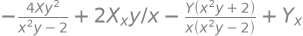

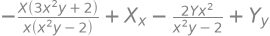

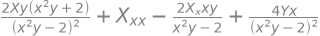

True


In [3]:
# B: Janet basis from Schwarz, Example 5.13, ranking Y > X and y > x
from sympy import Function, Symbol, diff
from delierium.infinitesimals import is_janet_basis_of_ode
ys = Symbol("y")
X, Y = Function("X")(ys, x), Function("Y")(ys, x)
B = [
    X.diff(ys),
    Y.diff(x) + 2*ys * X.diff(x)/x - (x*x*ys+2)*Y/(x*(x*x*ys-2)) - 4*ys*ys*X/(x*x*ys-2),
    Y.diff(ys) + X.diff(x) - 2*x*x*Y/(x*x*ys -2) - (3*x*x*ys + 2)*X/(x*(x*x*ys-2)),
    X.diff(x,x) - 2*x*ys*X.diff(x)/(x*x*ys-2) + 4*x*Y/(x*x*ys-2)**2 + 2*ys*X*(x*x*ys+2)/(x*x*ys-2)**2
]
for _ in B:
    ltf(_, [y], {})
print(is_janet_basis_of_ode(B, ode, y, x, dependent_order=[Y, X], independent_order=[ys, x]))